In [5]:
!pip install tensorflow

   ---------------------------------------- 0.0/331.9 MB ? eta -:--:--
   ---------------------------------------- 2.4/331.9 MB 14.9 MB/s eta 0:00:23
    --------------------------------------- 6.3/331.9 MB 17.5 MB/s eta 0:00:19
   - -------------------------------------- 10.7/331.9 MB 19.2 MB/s eta 0:00:17
   - -------------------------------------- 14.7/331.9 MB 19.2 MB/s eta 0:00:17
   -- ------------------------------------- 18.1/331.9 MB 18.7 MB/s eta 0:00:17
   -- ------------------------------------- 21.5/331.9 MB 18.4 MB/s eta 0:00:17
   --- ------------------------------------ 26.2/331.9 MB 18.9 MB/s eta 0:00:17
   --- ------------------------------------ 31.5/331.9 MB 19.6 MB/s eta 0:00:16
   ---- ----------------------------------- 35.4/331.9 MB 19.7 MB/s eta 0:00:16
   ---- ----------------------------------- 39.1/331.9 MB 19.6 MB/s eta 0:00:15
   ----- ---------------------------------- 42.5/331.9 MB 19.2 MB/s eta 0:00:16
   ----- ---------------------------------- 45.9/33

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 6.33.0 which is incompatible.


Membuat generator data training dengan augmentasi...
Membuat generator data validasi (tanpa augmentasi)...
Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.

Kelas-kelas yang ditemukan:
{'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___h

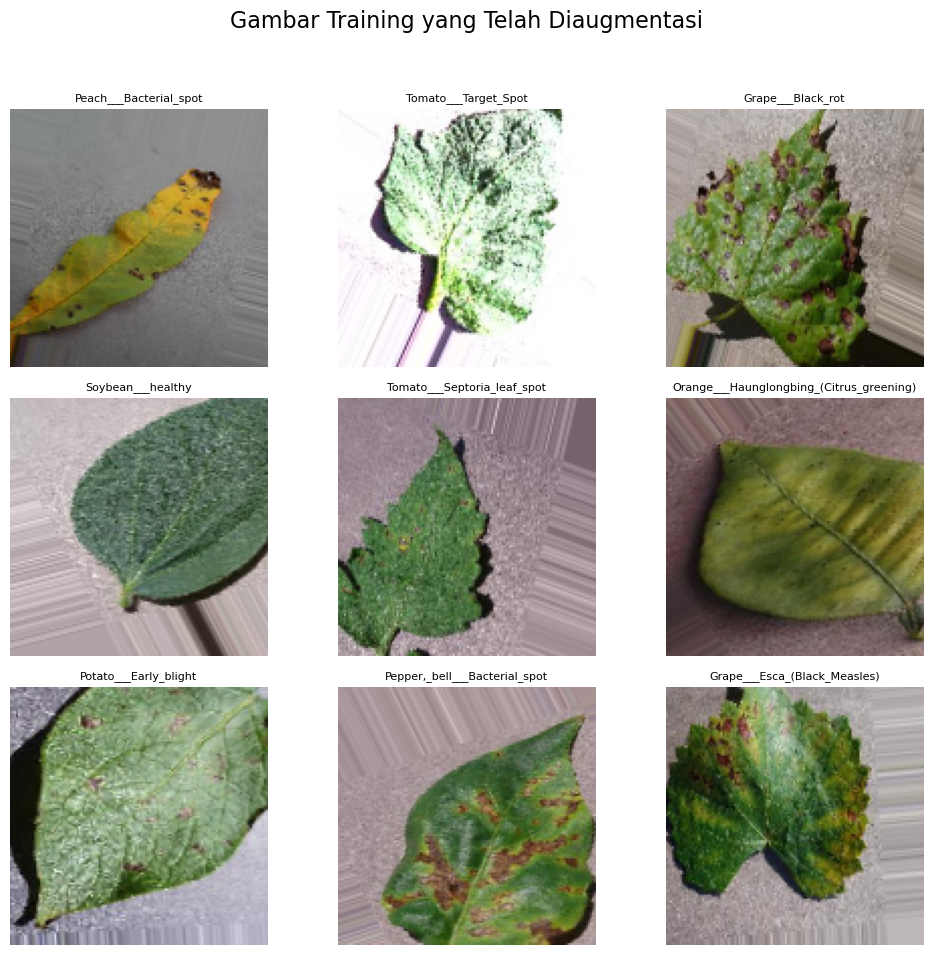

In [11]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import os

base_dir = 'C:/Users/ASUS/Documents/PlantLeafDataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)'
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'valid')

IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32 

print("Membuat generator data training dengan augmentasi...")

train_datagen = ImageDataGenerator(
    rescale=1./255,              
    rotation_range=40,             
    width_shift_range=0.2,          
    height_shift_range=0.2,        
    shear_range=0.2,             
    zoom_range=0.2,               
    horizontal_flip=True,          
    fill_mode='nearest'
)

print("Membuat generator data validasi (tanpa augmentasi)...")

validation_datagen = ImageDataGenerator(
    rescale=1./255                 
)


train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'      
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH), 
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print("\nKelas-kelas yang ditemukan:")
class_indices = train_generator.class_indices
print(class_indices)
print(f"\nBerhasil menemukan {len(class_indices)} kelas.")

images, labels = next(train_generator)

print("\nMenampilkan contoh gambar hasil augmentasi dari batch pertama:")
plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    class_name = [k for k, v in class_indices.items() if v == labels[i].argmax()][0]
    plt.title(class_name, fontsize=8)
    plt.axis("off")

plt.suptitle("Gambar Training yang Telah Diaugmentasi", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()